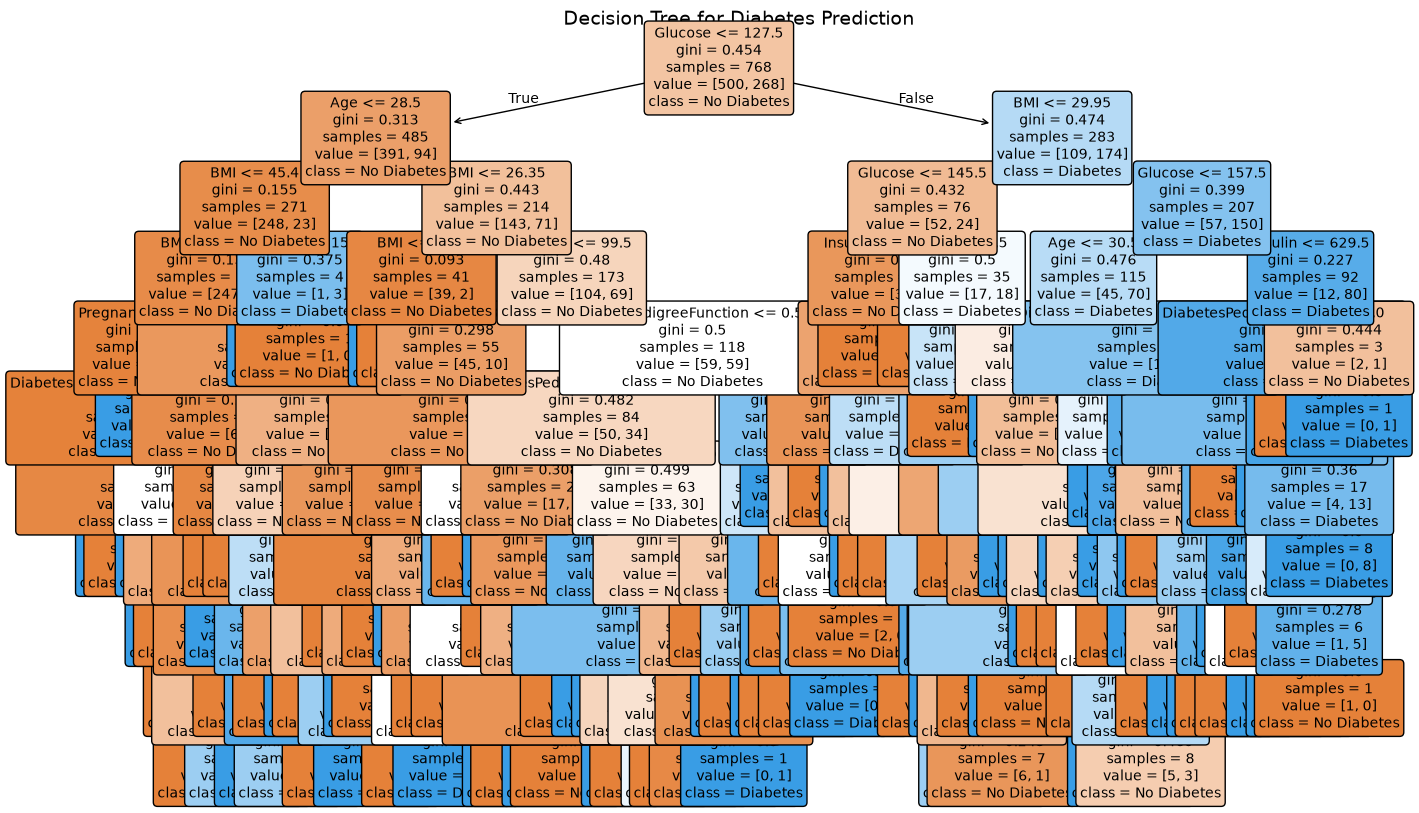

EXTRACTED DECISION TREE RULES:
|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 45.40
|   |   |   |--- BMI <= 30.95
|   |   |   |   |--- Pregnancies <= 7.50
|   |   |   |   |   |--- DiabetesPedigreeFunction <= 0.67
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- DiabetesPedigreeFunction >  0.67
|   |   |   |   |   |   |--- DiabetesPedigreeFunction <= 0.69
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- DiabetesPedigreeFunction >  0.69
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Pregnancies >  7.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- BMI >  30.95
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.50
|   |   |   |   |   |--- BloodPressure <= 53.00
|   |   |   |   |   |   |--- BMI <= 32.45
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- BMI >  32.45
|   |   |   |   |   |   |   |--- Insulin <= 31.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Ins

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# 1. Load the dataset
df = pd.read_csv(r"/workspaces/RapidSegment/diabetes.csv")

# 2. Separate independent features from target response matrix
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# 3. Initialize and fit shallow tree to keep rule extraction interpretive
clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X, y)

# 4. Generate the High-Resolution Plot Graph
plt.figure(figsize=(16, 10))
plot_tree(
    clf, 
    feature_names=X.columns, 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Decision Tree for Diabetes Prediction", fontsize=14)
plt.savefig("diabetes_tree.png", bbox_inches="tight", dpi=300)
plt.show()

# 5. Extract and print raw split decisions as plain text rules
tree_rules = export_text(clf, feature_names=list(X.columns))
print("=" * 50)
print("EXTRACTED DECISION TREE RULES:")
print("=" * 50)
print(tree_rules)

In [3]:
from rapidsegment import *

In [5]:
my_search_grid = {
    "min_sample_size": [10000,5000, 1000],  # Example values for min_sample_size   
    "min_lift": [2.0,1.5]
}


# Initialize the builder
builder = StrategicSegmentBuilder(
    target="Outcome",
    # n_jobs=-1,
    min_sample_size=10,
    min_lift=1.0,
    min_events = 0,
    top_n_vars=15,
    max_segments=10,
    enable_diversity=False,
    max_feature_reuse=99,
    enable_1way=True,  # Include 1-way rules from final output
    enable_2way=True,  # Exclude 2-way rules from final output
    enable_3way=True,  # Exclude 3-way rules from final output
    feature_groups=None,
    ignore_features=None,
    param_grid=None
)


data = UniversalDataLoader(file_path=r"/workspaces/RapidSegment/diabetes.csv").load()

segments_df = builder.extract_segments(data)
final_eval = builder.evaluate_final_coverage(data)

2026-07-12 15:18:07,528 | INFO     | [builder.py:337] | DuckDB Configured: Threads=4/4, MemoryLimit=7GB
2026-07-12 15:18:07,541 | INFO     | [builder.py:373] | Iteration 1 | Remaining Volume: 768 | Base Rate: 34.90%


2026-07-12 15:18:07,966 | INFO     | [builder.py:509] | Feature Usage Tracker Update -> 'Glucose' used count = 1
2026-07-12 15:18:07,966 | INFO     | [builder.py:509] | Feature Usage Tracker Update -> 'DiabetesPedigreeFunction' used count = 1
2026-07-12 15:18:07,967 | INFO     | [builder.py:509] | Feature Usage Tracker Update -> 'BMI' used count = 1
2026-07-12 15:18:07,967 | INFO     | [builder.py:524] | Segment 1 Captured (Size Floor: 10 | Lift Floor: 1.0): Glucose >= 166.50 AND (DiabetesPedigreeFunction >= 0.32 AND DiabetesPedigreeFunction < 0.53) AND (BMI >= 29.85 AND BMI < 40.85)
2026-07-12 15:18:07,978 | INFO     | [builder.py:373] | Iteration 2 | Remaining Volume: 755 | Base Rate: 33.77%
2026-07-12 15:18:08,457 | INFO     | [builder.py:509] | Feature Usage Tracker Update -> 'Glucose' used count = 2
2026-07-12 15:18:08,457 | INFO     | [builder.py:509] | Feature Usage Tracker Update -> 'DiabetesPedigreeFunction' used count = 2
2026-07-12 15:18:08,458 | INFO     | [builder.py:524] 

In [6]:
from prettytable import PrettyTable
import pandas as pd
table = PrettyTable()
table.field_names = list(pd.DataFrame(final_eval).columns)
for _, row in pd.DataFrame(final_eval).iterrows():
    table.add_row(list(row))
print(table)

+---------+-------------+---------------+-------------------+--------------------+--------------------+--------------------+
| segment | total_count | target_events |   response_rate   | base_response_rate |    capture_rate    |        lift        |
+---------+-------------+---------------+-------------------+--------------------+--------------------+--------------------+
|   0.0   |    654.0    |     163.0     | 24.92354740061162 | 34.89583333333333  |      85.15625      | 0.7142270299876764 |
|   1.0   |     13.0    |      13.0     |       100.0       | 34.89583333333333  | 1.6927083333333333 | 2.865671641791045  |
|   2.0   |     10.0    |      10.0     |       100.0       | 34.89583333333333  | 1.3020833333333335 | 2.865671641791045  |
|   3.0   |     10.0    |      10.0     |       100.0       | 34.89583333333333  | 1.3020833333333335 | 2.865671641791045  |
|   4.0   |     14.0    |      13.0     | 92.85714285714286 | 34.89583333333333  | 1.8229166666666667 | 2.660980810234542  |


In [7]:
print("--- FULL SEGMENT RULES ---\n")

for index, row in pd.DataFrame(segments_df).iterrows():
    print(f"Segment ID: {row['segment_id']}")
    print(f"Raw Rule:   {row['rule_string']}")
    print(f"SQL Filter: {row['sql_filter']}")
    print("-" * 50)

--- FULL SEGMENT RULES ---

Segment ID: 1
Raw Rule:   Glucose=[166.50, inf) & DiabetesPedigreeFunction=[0.32, 0.53) & BMI=[29.85, 40.85)
SQL Filter: Glucose >= 166.50 AND (DiabetesPedigreeFunction >= 0.32 AND DiabetesPedigreeFunction < 0.53) AND (BMI >= 29.85 AND BMI < 40.85)
--------------------------------------------------
Segment ID: 2
Raw Rule:   Glucose=[166.50, inf) & DiabetesPedigreeFunction=[0.72, 1.11)
SQL Filter: Glucose >= 166.50 AND (DiabetesPedigreeFunction >= 0.72 AND DiabetesPedigreeFunction < 1.11)
--------------------------------------------------
Segment ID: 3
Raw Rule:   Glucose=[154.50, 166.50) & BMI=[29.85, 40.85) & Insulin=(-inf, 14.50)
SQL Filter: (Glucose >= 154.50 AND Glucose < 166.50) AND (BMI >= 29.85 AND BMI < 40.85) AND Insulin < 14.50
--------------------------------------------------
Segment ID: 4
Raw Rule:   Glucose=[165.50, inf) & BMI=[40.85, inf)
SQL Filter: Glucose >= 165.50 AND BMI >= 40.85
--------------------------------------------------
Segment 